<div style="border-bottom: 2px solid #1f2a44; padding-bottom: 14px; margin-bottom: 22px;">
  <div style="display: flex; align-items: center; justify-content: space-between; gap: 24px;">
    <img src="../assets/branding/logoUgrupo.png" alt="Universidad del Magdalena y GIDSYC" style="height: 76px; max-width: 34%; object-fit: contain;">
    <div style="text-align: center; flex: 1; min-width: 260px;">
      <div style="font-size: 14px; letter-spacing: 0.04em; text-transform: uppercase; color: #5b6472;">Modelos de difusión para IA generativa</div>
      <div style="font-size: 15px; font-weight: 700; color: #667085; margin-top: 6px;">Notebook 09</div>
      <div style="font-size: 26px; font-weight: 700; color: #1f2a44; margin-top: 2px;">Score matching e intuición geométrica</div>
      <div style="font-size: 14px; color: #5b6472; margin-top: 8px;">Semillero GIDSYC | Facultad de Ingenierías | Programa de Ingeniería de Sistemas</div>
    </div>
    <img src="../assets/branding/logo_semillero.png" alt="Semillero GIDSYC" style="height: 74px; object-fit: contain;">
  </div>
</div>

<div style="display: flex; justify-content: space-between; gap: 16px; color: #3f4754; font-size: 14px; margin-bottom: 20px; flex-wrap: wrap;">
  <div><strong>Grupo:</strong> GIDSYC</div>
  <div><strong>Unidad:</strong> Semillero GIDSYC</div>
  <div><strong>Universidad:</strong> Universidad del Magdalena</div>
  <div><strong>Periodo:</strong> 2026-I</div>
</div>

## Pregunta directriz

> ¿Qué aprende realmente un modelo de denoising cuando predice ruido?

Hasta el notebook 08 trabajamos con DDPM desde la perspectiva discreta: se añade ruido, se entrena una red para predecir ese ruido y se recorre una cadena inversa. Esa descripción es suficiente para implementar modelos generativos funcionales, pero todavía oculta una lectura geométrica central: predecir ruido en datos perturbados está estrechamente relacionado con estimar el score de una distribución.

El score de una densidad $p$ se define como el gradiente del logaritmo de la densidad:

$$
s(x)=\nabla_x\log p(x).
$$

Este campo vectorial apunta hacia direcciones de incremento local de densidad. En dos dimensiones se puede visualizar. En imágenes reales no podemos dibujarlo directamente, pero el principio matemático es el mismo.

## Objetivos

Al finalizar este notebook, el estudiante debería estar en capacidad de:

1. Definir el score de una distribución y distinguirlo de la densidad.
2. Calcular e interpretar el score analítico de una mezcla gaussiana.
3. Formular el objetivo de denoising score matching.
4. Explicar por qué predecir ruido permite estimar un score perturbado.
5. Entrenar una red pequeña para aproximar el score en un problema 2D.
6. Visualizar campos score verdaderos y aprendidos.
7. Conectar score matching con la formulación DDPM usada en los notebooks anteriores.

## Marco conceptual

Una densidad indica dónde hay probabilidad. El score indica hacia dónde aumenta localmente esa densidad. Esta diferencia es importante: un modelo score-based no necesita producir directamente el valor normalizado de $p(x)$; necesita aproximar un campo de direcciones.

Para una distribución compleja, el score no suele estar disponible de forma analítica. Score matching propone aprenderlo a partir de muestras. En la versión que usaremos aquí, las muestras se perturban con ruido gaussiano y la red aprende a predecir el ruido añadido. Esa tarea es la misma que ya apareció en DDPM, pero ahora la leemos como estimación de un campo vectorial.

El experimento será bidimensional. No porque las imágenes sean bidimensionales en este sentido, sino porque dos dimensiones permiten ver el campo. Esta simplificación funciona como un microscopio matemático: sacrifica realismo visual para hacer visible una estructura que en imágenes queda oculta en alta dimensión.

## Formulación matemática

Sea $p(x)$ una densidad diferenciable sobre $\mathbb{R}^d$. Su score se define como

$$
s(x)
=
\nabla_x\log p(x)
=
\frac{\nabla_x p(x)}{p(x)}.
$$

Si $x$ está en una región donde la densidad aumenta rápidamente, el score tendrá mayor magnitud. Si $x$ está cerca de una región de alta densidad local, el campo tenderá a apuntar hacia esa región.

En denoising score matching perturbamos una muestra limpia $x_0\sim p_{\mathrm{data}}$ mediante

$$
x_\sigma
=
x_0+\sigma\epsilon,
\qquad
\epsilon\sim\mathcal{N}(0,I).
$$

La distribución condicional de la perturbación es

$$
q_\sigma(x_\sigma\mid x_0)
=
\mathcal{N}(x_\sigma;x_0,\sigma^2 I).
$$

Su score condicional se calcula explícitamente:

$$
\nabla_{x_\sigma}
\log q_\sigma(x_\sigma\mid x_0)
=
-
\frac{x_\sigma-x_0}{\sigma^2}
=
-
\frac{\epsilon}{\sigma}.
$$

Por tanto, si una red predice el ruido añadido,

$$
\epsilon_\theta(x_\sigma,\sigma)\approx\epsilon,
$$

entonces induce una estimación del score perturbado:

$$
s_\theta(x_\sigma,\sigma)
\approx
-
\frac{\epsilon_\theta(x_\sigma,\sigma)}{\sigma}.
$$

Esta es la conexión formal con DDPM: la red de predicción de ruido puede interpretarse como una red de score bajo una escala apropiada.

<div style="margin: 18px 0 10px 0; text-align: center;">
  <img src="../assets/figures/formulacion_score_matching.png" alt="Formulación de score matching" style="max-width: 100%; border: 1px solid #d0d7de; border-radius: 6px;" />
</div>

<div style="text-align: center; color: #4a5568; font-size: 0.95em; margin-bottom: 6px;">
  Score matching conecta campos de densidad, perturbaciones gaussianas y predicción de ruido.
</div>

## Preparación del entorno

El notebook usa un experimento sintético 2D y una red pequeña en PyTorch. La ejecución es barata: no se entrena una U-Net ni se cargan imágenes. El objetivo es aislar la geometría del score.

In [1]:
import math
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

CWD = Path.cwd()
if CWD.name == "notebooks":
    ROOT = CWD.parent
elif (CWD / "src" / "difusion").exists():
    ROOT = CWD
else:
    ROOT = CWD / "courses" / "modelos_difusion_ia_generativa"

SEED = 20260425
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("PyTorch:", torch.__version__)
print("Dispositivo:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(DEVICE))

PyTorch: 2.8.0+cu126
Dispositivo: cuda:0
GPU: NVIDIA RTX A6000


## Distribución de referencia

Usaremos una mezcla de tres gaussianas isotrópicas en $\mathbb{R}^2$:

$$
p(x)
=
\sum_{k=1}^{K}
\pi_k\,
\mathcal{N}(x;\mu_k,\sigma_0^2 I).
$$

Esta distribución tiene varias regiones de alta densidad. Por eso resulta útil: el score no apunta siempre hacia un único centro, sino que cambia según la posición relativa de $x$.

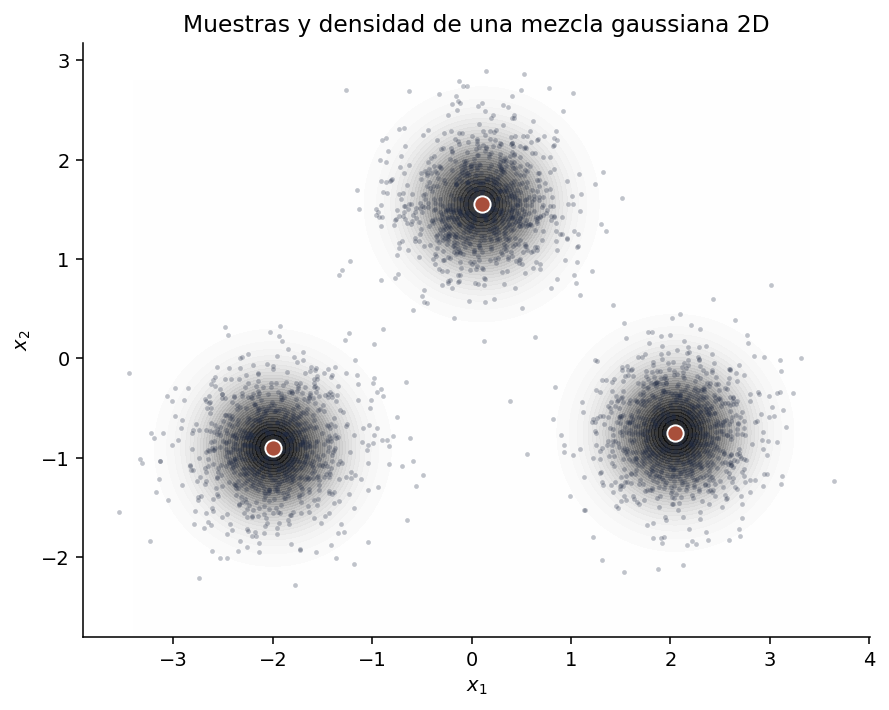

In [2]:
means_np = np.array([[-2.0, -0.9], [0.1, 1.55], [2.05, -0.75]], dtype=np.float32)
weights_np = np.array([0.34, 0.32, 0.34], dtype=np.float32)
data_sigma = 0.45
dim = 2


def sample_mixture_np(n, sigma=data_sigma, rng=None):
    rng = np.random.default_rng(SEED) if rng is None else rng
    comp = rng.choice(len(means_np), size=n, p=weights_np)
    x = means_np[comp] + sigma * rng.normal(size=(n, dim)).astype(np.float32)
    return x.astype(np.float32), comp


def mixture_density_np(points, noise_sigma=0.0):
    sigma2 = data_sigma**2 + noise_sigma**2
    diff = points[:, None, :] - means_np[None, :, :]
    exponent = -0.5 * np.sum(diff**2, axis=-1) / sigma2
    normalizer = 1.0 / (2.0 * np.pi * sigma2)
    components = normalizer * np.exp(exponent) * weights_np[None, :]
    return components.sum(axis=1), components


def mixture_score_np(points, noise_sigma=0.0):
    sigma2 = data_sigma**2 + noise_sigma**2
    density, components = mixture_density_np(points, noise_sigma=noise_sigma)
    responsibilities = components / np.maximum(density[:, None], 1e-12)
    component_scores = -(points[:, None, :] - means_np[None, :, :]) / sigma2
    return np.sum(responsibilities[:, :, None] * component_scores, axis=1)


grid_x = np.linspace(-3.4, 3.4, 180)
grid_y = np.linspace(-2.8, 2.8, 160)
xx, yy = np.meshgrid(grid_x, grid_y)
grid = np.column_stack([xx.ravel(), yy.ravel()]).astype(np.float32)

samples, components = sample_mixture_np(2_500, rng=np.random.default_rng(SEED))
density, _ = mixture_density_np(grid)
zz = density.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7.6, 5.2))
ax.contourf(xx, yy, zz, levels=35, cmap="Greys", alpha=0.88)
ax.scatter(samples[:, 0], samples[:, 1], s=6, alpha=0.28, color="#1f2a44", linewidths=0)
ax.scatter(means_np[:, 0], means_np[:, 1], s=70, color="#a84f3b", edgecolor="white", linewidth=1.0)
ax.set_title("Muestras y densidad de una mezcla gaussiana 2D")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_aspect("equal")
fig.tight_layout()

## Score analítico de una mezcla gaussiana

Para una mezcla gaussiana, el score puede escribirse en forma cerrada. Definamos la responsabilidad posterior de la componente $k$:

$$
r_k(x)
=
\frac{
\pi_k\,\mathcal{N}(x;\mu_k,\sigma_0^2 I)
}{
\sum_{j=1}^{K}\pi_j\,\mathcal{N}(x;\mu_j,\sigma_0^2 I)
}.
$$

El score de la mezcla es

$$
\nabla_x\log p(x)
=
\sum_{k=1}^{K}
r_k(x)
\frac{\mu_k-x}{\sigma_0^2}.
$$

Esta ecuación muestra por qué el campo cambia suavemente entre regiones. Lejos de un modo, varias componentes pueden competir; cerca de una componente dominante, el score se parece al score de una gaussiana individual.

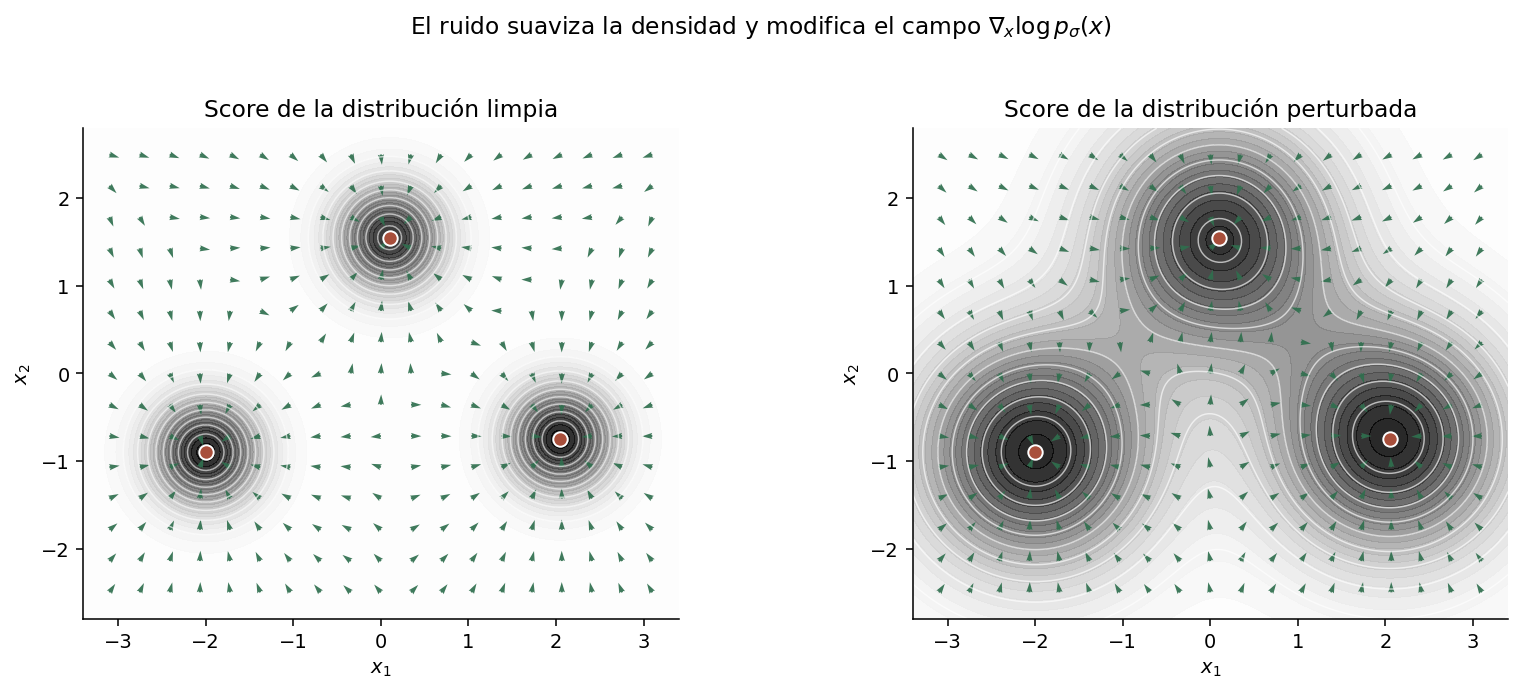

In [3]:
def plot_score_field(ax, noise_sigma=0.0, title=""):
    density, _ = mixture_density_np(grid, noise_sigma=noise_sigma)
    zz = density.reshape(xx.shape)
    ax.contourf(xx, yy, zz, levels=28, cmap="Greys", alpha=0.86)
    ax.contour(xx, yy, zz, levels=9, colors="white", linewidths=0.75, alpha=0.65)

    qx = np.linspace(-3.1, 3.1, 19)
    qy = np.linspace(-2.5, 2.5, 15)
    qxx, qyy = np.meshgrid(qx, qy)
    pts = np.column_stack([qxx.ravel(), qyy.ravel()]).astype(np.float32)
    score = mixture_score_np(pts, noise_sigma=noise_sigma)
    norm = np.linalg.norm(score, axis=1, keepdims=True)
    direction = score / np.maximum(norm, 1e-8)
    ax.quiver(
        pts[:, 0],
        pts[:, 1],
        direction[:, 0],
        direction[:, 1],
        color="#2f6f4e",
        angles="xy",
        scale_units="xy",
        scale=8.5,
        width=0.004,
        alpha=0.92,
    )
    ax.scatter(means_np[:, 0], means_np[:, 1], s=55, color="#a84f3b", edgecolor="white", linewidth=1.0)
    ax.set_title(title)
    ax.set_xlim(-3.4, 3.4)
    ax.set_ylim(-2.8, 2.8)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_aspect("equal")


fig, axes = plt.subplots(1, 2, figsize=(12, 4.7))
plot_score_field(axes[0], noise_sigma=0.0, title="Score de la distribución limpia")
plot_score_field(axes[1], noise_sigma=0.85, title="Score de la distribución perturbada")
fig.suptitle(r"El ruido suaviza la densidad y modifica el campo $\nabla_x \log p_\sigma(x)$", y=1.03)
fig.tight_layout()

## Perturbación y objetivo de denoising

Para entrenar desde muestras, no necesitamos conocer el score analítico de $p$. Tomamos una muestra limpia, añadimos ruido y usamos el ruido conocido como señal supervisada:

$$
x_\sigma=x_0+\sigma\epsilon.
$$

El objetivo de predicción de ruido es

$$
\mathcal{L}(\theta)
=
\mathbb{E}
\left[
\left\|
\epsilon
-
\epsilon_\theta(x_\sigma,\sigma)
\right\|_2^2
\right].
$$

Al minimizar esta pérdida, la red aprende el promedio condicional del ruido dado el punto perturbado. Ese promedio está relacionado con el score marginal de la distribución perturbada.

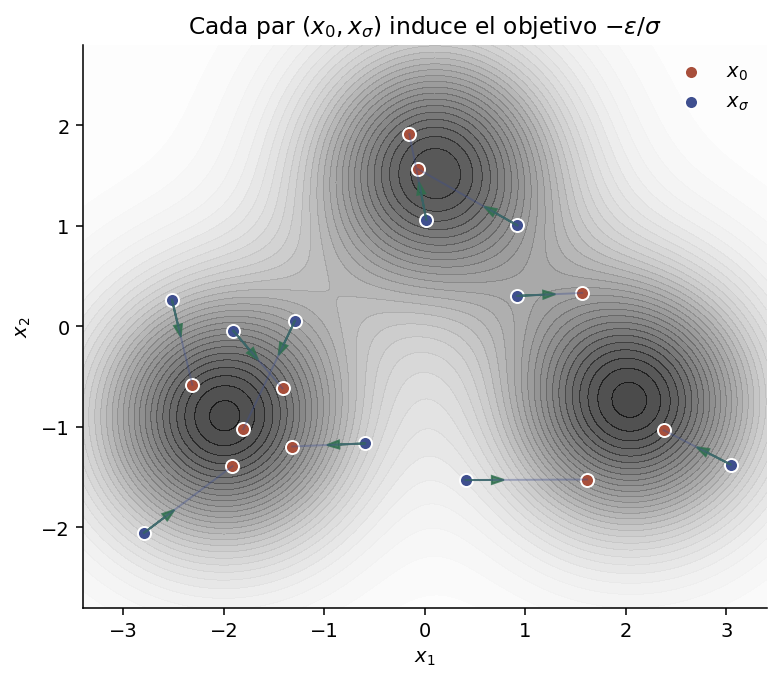

In [4]:
rng = np.random.default_rng(SEED + 1)
x0, _ = sample_mixture_np(10, rng=rng)
sigma_demo = 0.85
eps = rng.normal(size=x0.shape).astype(np.float32)
x_sigma = x0 + sigma_demo * eps
target_score = -eps / sigma_demo

density_s, _ = mixture_density_np(grid, noise_sigma=sigma_demo)
zz_s = density_s.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7.2, 5.0))
ax.contourf(xx, yy, zz_s, levels=30, cmap="Greys", alpha=0.72)
ax.scatter(x0[:, 0], x0[:, 1], s=45, color="#a84f3b", edgecolor="white", linewidth=1.0, label="$x_0$")
ax.scatter(x_sigma[:, 0], x_sigma[:, 1], s=45, color="#3f4f8f", edgecolor="white", linewidth=1.0, label="$x_\\sigma$")
for clean, noisy, score_vec in zip(x0, x_sigma, target_score):
    ax.plot([clean[0], noisy[0]], [clean[1], noisy[1]], color="#3f4f8f", alpha=0.38, linewidth=1.0)
    direction = score_vec / max(np.linalg.norm(score_vec), 1e-8)
    ax.arrow(
        noisy[0],
        noisy[1],
        0.38 * direction[0],
        0.38 * direction[1],
        head_width=0.08,
        head_length=0.12,
        length_includes_head=True,
        color="#2f6f4e",
        alpha=0.82,
    )
ax.set_title(r"Cada par $(x_0,x_\sigma)$ induce el objetivo $-\epsilon/\sigma$")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.legend(frameon=False, loc="upper right")
ax.set_aspect("equal")
fig.tight_layout()

## Entrenamiento de una red de score

Entrenaremos una red pequeña que recibe $(x_\sigma,\log\sigma)$ y predice $\epsilon$. Después convertimos esa predicción en score mediante

$$
s_\theta(x_\sigma,\sigma)
=
-
\frac{\epsilon_\theta(x_\sigma,\sigma)}{\sigma}.
$$

La elección de predecir ruido no es accidental: mantiene la conexión directa con DDPM. Lo que cambia es la interpretación del resultado.

In [5]:
means = torch.tensor(means_np, dtype=torch.float32, device=DEVICE)
weights = torch.tensor(weights_np, dtype=torch.float32, device=DEVICE)


def sample_mixture_torch(n):
    comp = torch.multinomial(weights, n, replacement=True)
    x = means[comp] + data_sigma * torch.randn(n, dim, device=DEVICE)
    return x, comp


class EpsilonMLP(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, 2),
        )

    def forward(self, x_sigma, sigma):
        log_sigma = torch.log(sigma).view(-1, 1)
        features = torch.cat([x_sigma, log_sigma], dim=1)
        return self.net(features)


model = EpsilonMLP(hidden=128).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3)

TRAIN_STEPS = 3_000
BATCH_SIZE = 1_024
SIGMA_MIN = 0.05
SIGMA_MAX = 1.50

loss_history = []
start = time.perf_counter()
model.train()
for step in range(1, TRAIN_STEPS + 1):
    x0_batch, _ = sample_mixture_torch(BATCH_SIZE)
    log_sigma = torch.empty(BATCH_SIZE, device=DEVICE).uniform_(math.log(SIGMA_MIN), math.log(SIGMA_MAX))
    sigma_batch = torch.exp(log_sigma)
    eps_batch = torch.randn_like(x0_batch)
    x_sigma_batch = x0_batch + sigma_batch[:, None] * eps_batch

    eps_pred = model(x_sigma_batch, sigma_batch)
    loss = torch.mean((eps_batch - eps_pred) ** 2)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    loss_history.append(float(loss.detach().cpu()))
    if step % 500 == 0:
        print(f"paso {step:04d}/{TRAIN_STEPS} | loss={loss_history[-1]:.4f}")

if DEVICE.type == "cuda":
    torch.cuda.synchronize()
elapsed = time.perf_counter() - start
print(f"Tiempo total de entrenamiento: {elapsed:.2f} s")

paso 0500/3000 | loss=0.7371
paso 1000/3000 | loss=0.7332
paso 1500/3000 | loss=0.7274
paso 2000/3000 | loss=0.7093
paso 2500/3000 | loss=0.6956
paso 3000/3000 | loss=0.7473
Tiempo total de entrenamiento: 13.34 s


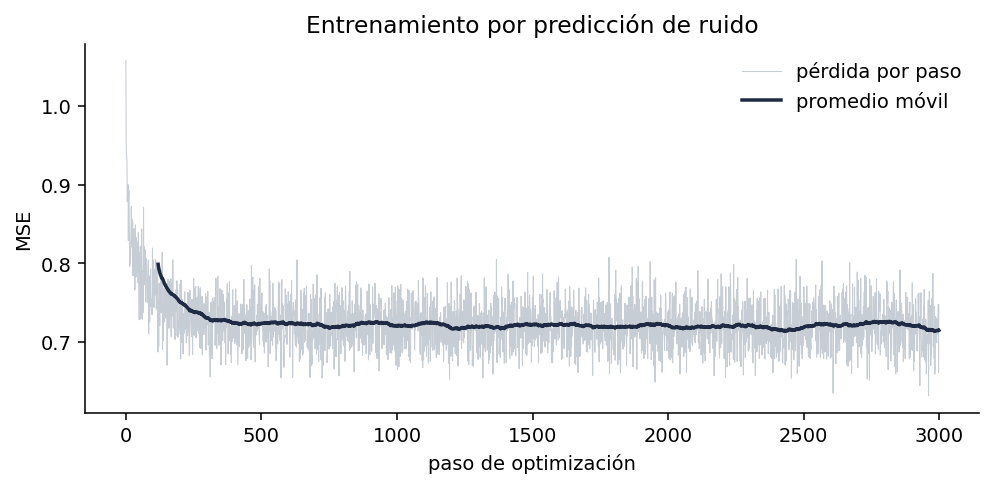

In [6]:
fig, ax = plt.subplots(figsize=(7.2, 3.6))
ax.plot(loss_history, color="#9aa4b2", linewidth=0.55, alpha=0.55, label="pérdida por paso")
window = 120
if len(loss_history) >= window:
    kernel = np.ones(window) / window
    moving = np.convolve(np.asarray(loss_history), kernel, mode="valid")
    ax.plot(np.arange(window - 1, len(loss_history)), moving, color="#1f2a44", linewidth=1.8, label="promedio móvil")
ax.set_title("Entrenamiento por predicción de ruido")
ax.set_xlabel("paso de optimización")
ax.set_ylabel("MSE")
ax.legend(frameon=False)
fig.tight_layout()

La pérdida no debe esperarse cercana a cero. Dado un punto perturbado $x_\sigma$, pueden existir varios pares $(x_0,\epsilon)$ compatibles con esa observación. La red no aprende a recuperar el ruido exacto de cada ejemplo de manera determinista; aprende una predicción promedio que, bajo el objetivo de denoising, se relaciona con el score marginal perturbado.

## Score aprendido frente al score verdadero

Como la distribución 2D es conocida, podemos comparar el campo aprendido con el score analítico de la mezcla perturbada. Esta comparación no estaría disponible en un dataset real de imágenes, pero aquí sirve para validar la interpretación.

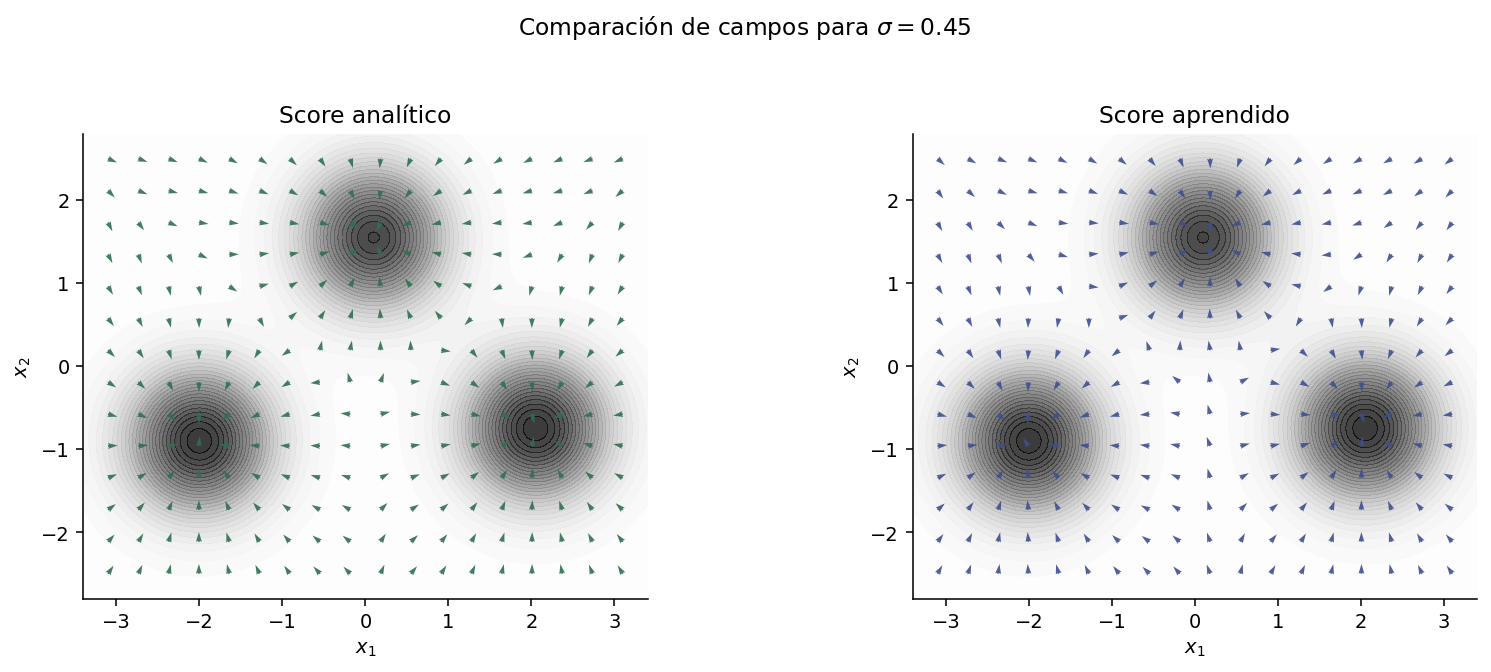

In [7]:
@torch.no_grad()
def learned_score_np(points_np, sigma_value):
    points = torch.tensor(points_np, dtype=torch.float32, device=DEVICE)
    sigma = torch.full((points.shape[0],), float(sigma_value), dtype=torch.float32, device=DEVICE)
    eps_pred = model(points, sigma)
    score = -eps_pred / sigma[:, None]
    return score.detach().cpu().numpy()


def plot_true_and_learned(sigma_value):
    qx = np.linspace(-3.1, 3.1, 18)
    qy = np.linspace(-2.5, 2.5, 14)
    qxx, qyy = np.meshgrid(qx, qy)
    pts = np.column_stack([qxx.ravel(), qyy.ravel()]).astype(np.float32)
    true_score = mixture_score_np(pts, noise_sigma=sigma_value)
    pred_score = learned_score_np(pts, sigma_value)

    true_dir = true_score / np.maximum(np.linalg.norm(true_score, axis=1, keepdims=True), 1e-8)
    pred_dir = pred_score / np.maximum(np.linalg.norm(pred_score, axis=1, keepdims=True), 1e-8)

    density, _ = mixture_density_np(grid, noise_sigma=sigma_value)
    zz = density.reshape(xx.shape)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
    for ax, vectors, title, color in [
        (axes[0], true_dir, "Score analítico", "#2f6f4e"),
        (axes[1], pred_dir, "Score aprendido", "#3f4f8f"),
    ]:
        ax.contourf(xx, yy, zz, levels=28, cmap="Greys", alpha=0.78)
        ax.quiver(
            pts[:, 0],
            pts[:, 1],
            vectors[:, 0],
            vectors[:, 1],
            color=color,
            angles="xy",
            scale_units="xy",
            scale=8.5,
            width=0.004,
            alpha=0.9,
        )
        ax.set_title(title)
        ax.set_xlim(-3.4, 3.4)
        ax.set_ylim(-2.8, 2.8)
        ax.set_xlabel("$x_1$")
        ax.set_ylabel("$x_2$")
        ax.set_aspect("equal")
    fig.suptitle(fr"Comparación de campos para $\sigma={sigma_value}$", y=1.03)
    fig.tight_layout()
    return fig


fig = plot_true_and_learned(0.45)

## Denoising como movimiento en dirección de score

Una forma directa de interpretar el score aprendido es aplicar un pequeño desplazamiento desde $x_\sigma$ en la dirección $s_\theta(x_\sigma,\sigma)$. Ese desplazamiento no reemplaza una cadena generativa completa, pero muestra la relación geométrica entre denoising y movimiento hacia regiones de mayor densidad.

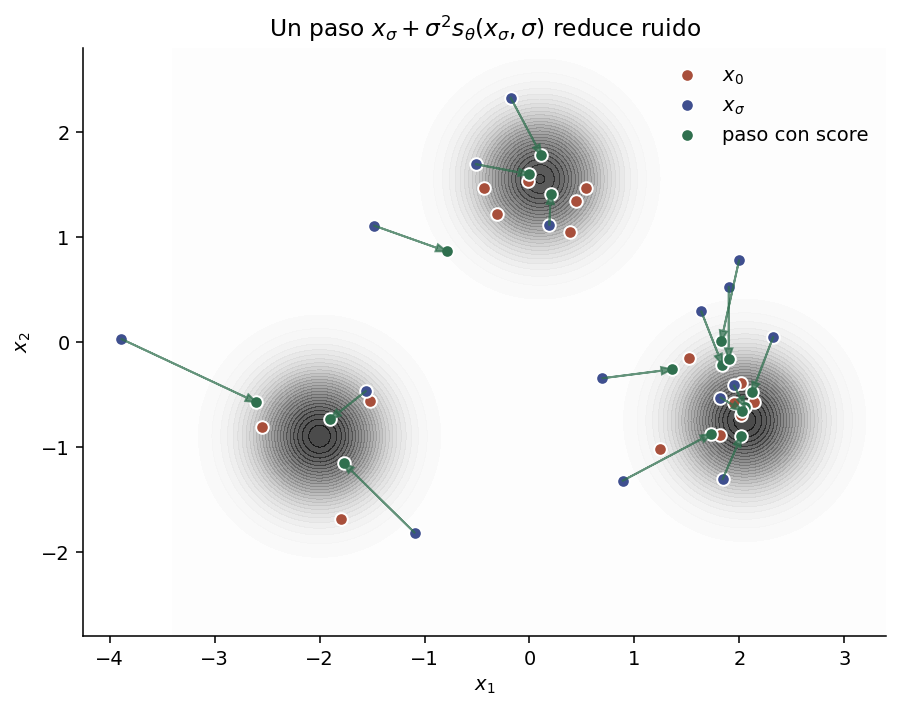

In [8]:
rng = np.random.default_rng(SEED + 7)
clean, _ = sample_mixture_np(16, rng=rng)
sigma_value = 0.75
eps = rng.normal(size=clean.shape).astype(np.float32)
noisy = clean + sigma_value * eps
score_pred = learned_score_np(noisy.astype(np.float32), sigma_value)
denoised_step = noisy + (sigma_value**2) * score_pred

density, _ = mixture_density_np(grid, noise_sigma=0.0)
zz = density.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7.5, 5.2))
ax.contourf(xx, yy, zz, levels=30, cmap="Greys", alpha=0.72)
ax.scatter(clean[:, 0], clean[:, 1], s=42, color="#a84f3b", edgecolor="white", linewidth=1.0, label="$x_0$")
ax.scatter(noisy[:, 0], noisy[:, 1], s=42, color="#3f4f8f", edgecolor="white", linewidth=1.0, label="$x_\\sigma$")
ax.scatter(denoised_step[:, 0], denoised_step[:, 1], s=42, color="#2f6f4e", edgecolor="white", linewidth=1.0, label="paso con score")
for a, b in zip(noisy, denoised_step):
    ax.arrow(
        a[0],
        a[1],
        b[0] - a[0],
        b[1] - a[1],
        head_width=0.07,
        head_length=0.10,
        length_includes_head=True,
        color="#2f6f4e",
        alpha=0.72,
    )
ax.set_title(r"Un paso $x_\sigma+\sigma^2 s_\theta(x_\sigma,\sigma)$ reduce ruido")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.legend(frameon=False, loc="upper right")
ax.set_aspect("equal")
fig.tight_layout()

## Muestreo con dinámica de Langevin

Si disponemos de un score, podemos usarlo para mover partículas hacia regiones de alta densidad mientras conservamos ruido controlado. Una versión simple de dinámica de Langevin usa iteraciones de la forma

$$
x_{n+1}
=
x_n
+
\eta\,s_\theta(x_n,\sigma)
+
\sqrt{2\eta}\,z_n,
\qquad
z_n\sim\mathcal{N}(0,I).
$$

En la práctica se usa una secuencia de niveles de ruido. Aquí lo mostraremos solo como una visualización conceptual; el objetivo no es reemplazar DDPM, sino ver cómo un campo score puede inducir generación.

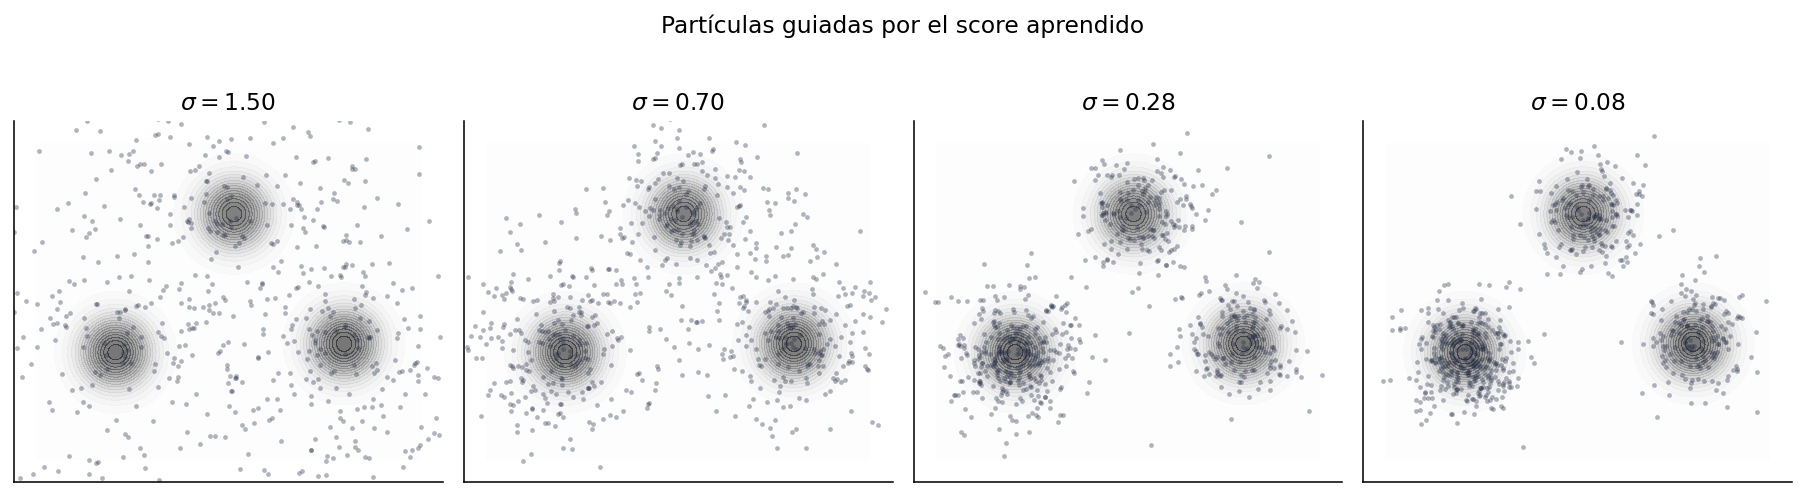

In [9]:
@torch.no_grad()
def annealed_langevin(model, n=700, sigmas=None, steps_per_sigma=45, step_scale=0.018):
    if sigmas is None:
        sigmas = torch.tensor([1.50, 1.00, 0.70, 0.45, 0.28, 0.16, 0.08], device=DEVICE)
    x = torch.randn(n, 2, device=DEVICE) * 2.2
    snapshots = []
    for sigma in sigmas:
        sigma_batch = torch.full((n,), float(sigma), device=DEVICE)
        step_size = step_scale * (float(sigma) / SIGMA_MIN) ** 2
        step_size = min(step_size, 0.12)
        for _ in range(steps_per_sigma):
            eps_pred = model(x, sigma_batch)
            score = -eps_pred / sigma_batch[:, None]
            noise = torch.randn_like(x)
            x = x + step_size * score + math.sqrt(2.0 * step_size) * noise
        snapshots.append((float(sigma), x.detach().cpu().numpy()))
    return snapshots


snapshots = annealed_langevin(model)
show_indices = [0, 2, 4, 6]

fig, axes = plt.subplots(1, len(show_indices), figsize=(13, 3.5))
clean_density, _ = mixture_density_np(grid, noise_sigma=0.0)
clean_zz = clean_density.reshape(xx.shape)
for ax, idx in zip(axes, show_indices):
    sigma_value, pts = snapshots[idx]
    ax.contourf(xx, yy, clean_zz, levels=25, cmap="Greys", alpha=0.55)
    ax.scatter(pts[:, 0], pts[:, 1], s=6, alpha=0.35, color="#1f2a44", linewidths=0)
    ax.set_title(fr"$\sigma={sigma_value:.2f}$")
    ax.set_xlim(-3.8, 3.8)
    ax.set_ylim(-3.2, 3.2)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")
fig.suptitle("Partículas guiadas por el score aprendido", y=1.04)
fig.tight_layout()

## Lectura crítica

Este notebook usa una distribución sintética porque permite verificar el campo verdadero. Esa claridad no existe en imágenes: no conocemos $p_{\mathrm{data}}(x)$ ni su gradiente. Por eso entrenamos una red para aproximar el score a partir de perturbaciones.

La conexión con DDPM es estricta pero debe leerse con cuidado. En DDPM entrenamos una red para predecir ruido en tiempos discretos. En score matching escribimos explícitamente el campo $s_\theta(x,\sigma)$. Bajo la parametrización de predicción de ruido,

$$
s_\theta(x_\sigma,\sigma)
\approx
-
\frac{\epsilon_\theta(x_\sigma,\sigma)}{\sigma}.
$$

Por tanto, score matching no contradice lo anterior. Reinterpreta el mismo tipo de entrenamiento como aprendizaje de campos vectoriales asociados a distribuciones perturbadas.

## Síntesis

El score de una distribución es el campo

$$
\nabla_x\log p(x).
$$

En regiones de baja densidad, este campo indica direcciones locales hacia zonas más probables. Denoising score matching entrena una red usando pares perturbados $(x_0,x_\sigma)$ y el ruido conocido $\epsilon$. La predicción de ruido induce una estimación del score perturbado mediante

$$
s_\theta(x_\sigma,\sigma)
\approx
-
\epsilon_\theta(x_\sigma,\sigma)/\sigma.
$$

El experimento 2D mostró densidad, score analítico, perturbaciones gaussianas, entrenamiento de una red pequeña, comparación de campos y una dinámica generativa basada en Langevin. Con esto queda preparado el puente hacia formulaciones continuas y hacia flow matching.

## Preguntas de discusión

1. ¿Por qué el score no es lo mismo que la densidad?
2. ¿Qué información geométrica contiene $\nabla_x\log p(x)$?
3. ¿Por qué el score condicional de $q_\sigma(x_\sigma\mid x_0)$ es $-\epsilon/\sigma$?
4. ¿Qué relación hay entre predicción de ruido y estimación de score?
5. ¿Por qué el experimento 2D permite validar visualmente algo que no podemos ver en imágenes?
6. ¿Qué limitaciones tiene interpretar un paso de denoising como generación completa?
7. ¿Cómo se conecta este notebook con las formulaciones continuas introducidas al inicio del curso?

## Continuidad

El siguiente notebook estudiará flow matching y transporte de probabilidad. Allí la generación se formulará mediante campos de velocidad que transportan una distribución inicial hacia una distribución de datos. La diferencia conceptual será importante: score matching aprende direcciones ligadas al gradiente de log-densidad, mientras que flow matching aprende un campo de transporte entre distribuciones.